### Regular Model Test

--- Model Parameters Inspection ---

Layer: conv1.weight
  Shape: (8, 3, 3, 3)
  Min:   -1.002785
  Max:   1.088972
  Mean:  0.061926
-----------------------------------


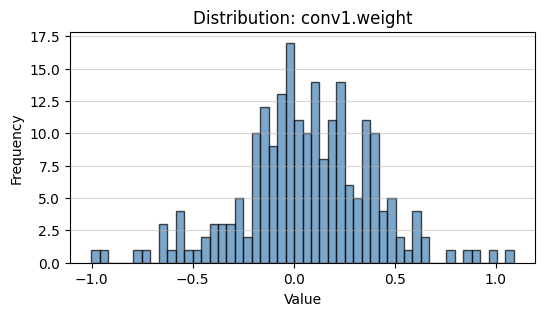

Layer: conv1.bias
  Shape: (8,)
  Min:   -0.588252
  Max:   0.276387
  Mean:  -0.233333
-----------------------------------


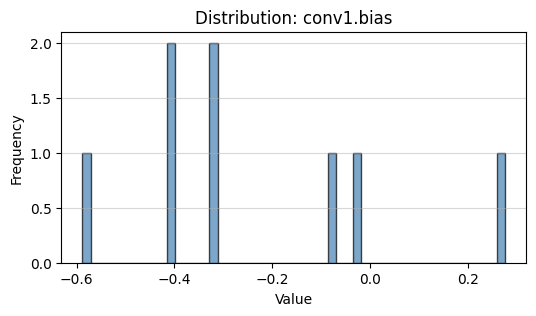

Layer: conv2.weight
  Shape: (16, 8, 3, 3)
  Min:   -1.130441
  Max:   1.002855
  Mean:  -0.006303
-----------------------------------


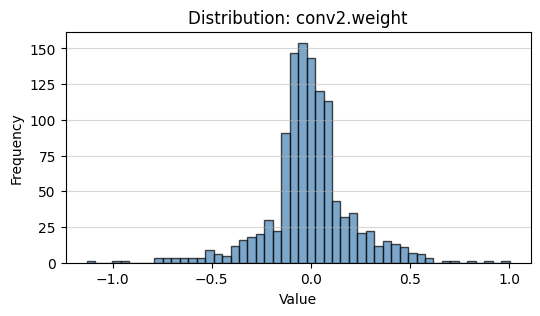

Layer: conv2.bias
  Shape: (16,)
  Min:   -0.308375
  Max:   0.443596
  Mean:  0.020610
-----------------------------------


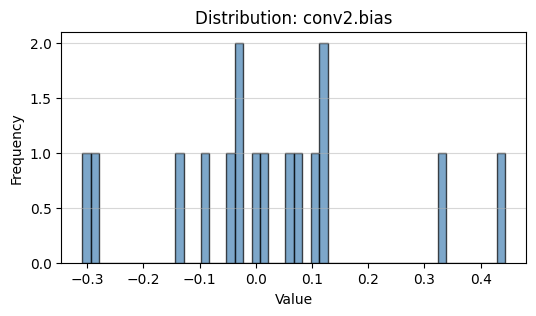

Layer: fc1.weight
  Shape: (32, 400)
  Min:   -1.392058
  Max:   1.305900
  Mean:  -0.002370
-----------------------------------


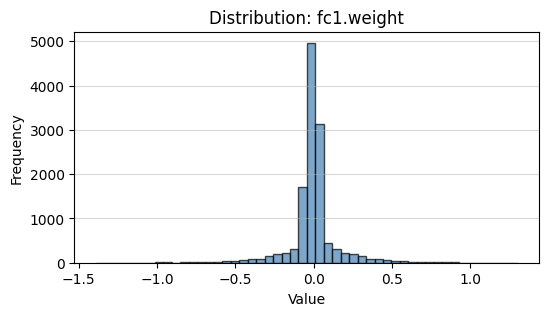

Layer: fc1.bias
  Shape: (32,)
  Min:   -0.378292
  Max:   0.412401
  Mean:  0.030460
-----------------------------------


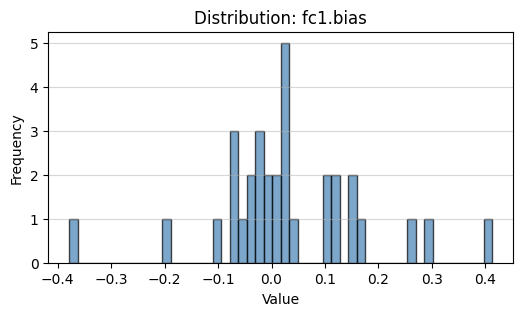

Layer: fc2.weight
  Shape: (8, 32)
  Min:   -1.628880
  Max:   0.879315
  Mean:  -0.053059
-----------------------------------


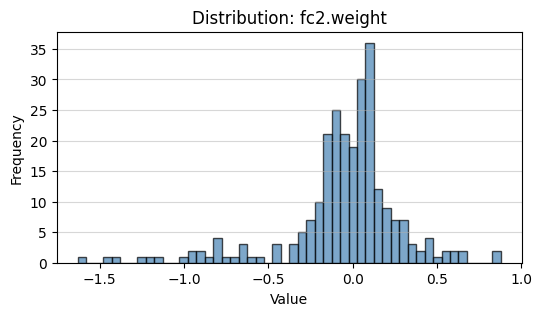

Layer: fc2.bias
  Shape: (8,)
  Min:   -0.403392
  Max:   0.409680
  Mean:  -0.046263
-----------------------------------


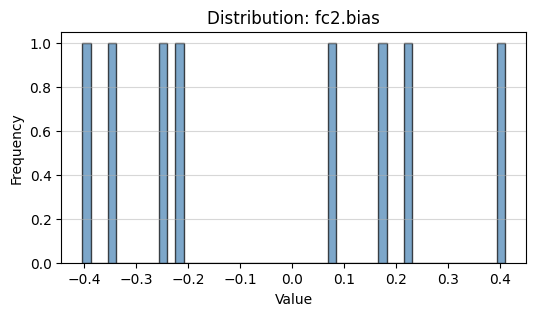

In [14]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 1. Re-define the Architecture (Required to load state_dict)
class MicroCNN(nn.Module):
    def __init__(self, num_classes=8, use_bias=True): 
        super(MicroCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, bias=use_bias) 
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, bias=use_bias)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(16 * 5 * 5, 32, bias=use_bias)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(32, num_classes, bias=use_bias)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

# 2. Load the Model
# We load it directly to the CPU for easier Numpy manipulation and plotting
model = MicroCNN(use_bias=True)
model.load_state_dict(torch.load('micro_cnn_blood.pth', map_location='cpu'))
model.eval()

# 3. Inspect the Parameters
print("--- Model Parameters Inspection ---\n")
for name, param in model.named_parameters():
    val = param.detach().numpy()
    print(f"Layer: {name}")
    print(f"  Shape: {val.shape}")
    print(f"  Min:   {val.min():.6f}")
    print(f"  Max:   {val.max():.6f}")
    print(f"  Mean:  {val.mean():.6f}")
    print("-" * 35)
    
    # Plot a histogram to visualize the distribution
    plt.figure(figsize=(6, 3))
    plt.hist(val.flatten(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    plt.title(f'Distribution: {name}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.5)
    plt.show()

### Model Quantization

In [15]:
import medmnist
from medmnist import INFO
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. Dataset Configuration
data_flag = 'bloodmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# 2. Data Transform (uint8 to float tensor [0.0, 1.0] for PyTorch math)
data_transform = transforms.Compose([
    transforms.ToTensor()
])

# 3. Load Datasets
print(f"Downloading/Loading {data_flag}...")
train_dataset = DataClass(split='train', transform=data_transform, download=True)
test_dataset = DataClass(split='test', transform=data_transform, download=True)

# 4. Define DataLoaders
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)

print(f"Success! Loaded {len(train_dataset)} training samples and {len(test_dataset)} testing samples.")

Downloading/Loading bloodmnist...
Success! Loaded 11959 training samples and 3421 testing samples.


In [16]:
import torch
import torch.nn as nn
import numpy as np

# 1. Re-define the standard FP32 Architecture
class MicroCNN(nn.Module):
    def __init__(self, num_classes=8, use_bias=True): 
        super(MicroCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, bias=use_bias) 
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, bias=use_bias)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(16 * 5 * 5, 32, bias=use_bias)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(32, num_classes, bias=use_bias)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

# 2. Load the trained FP32 model
# We map it directly to the CPU to safely convert the tensors to NumPy
model = MicroCNN(use_bias=True)
model.load_state_dict(torch.load('micro_cnn_blood.pth', map_location='cpu'))
model.eval()

# 3. Extract and store parameters for manual quantization
fp32_params = {}

# Iterate through only the layers that have weights (Conv2d and Linear)
for name, module in model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        fp32_params[name] = {
            # .detach().numpy() safely rips the values out of PyTorch's autograd graph
            'weight': module.weight.detach().numpy(),
            'bias': module.bias.detach().numpy() if module.bias is not None else None
        }

# 4. Verify the extraction
print("--- FP32 Parameters Successfully Extracted ---")
for layer_name, params in fp32_params.items():
    w = params['weight']
    b = params['bias']
    print(f"Layer: {layer_name}")
    print(f"  Weights: Shape {w.shape} | Min: {w.min():.6f} | Max: {w.max():.6f}")
    if b is not None:
        print(f"  Biases:  Shape {b.shape} | Min: {b.min():.6f} | Max: {b.max():.6f}")
    print("-" * 50)

--- FP32 Parameters Successfully Extracted ---
Layer: conv1
  Weights: Shape (8, 3, 3, 3) | Min: -1.002785 | Max: 1.088972
  Biases:  Shape (8,) | Min: -0.588252 | Max: 0.276387
--------------------------------------------------
Layer: conv2
  Weights: Shape (16, 8, 3, 3) | Min: -1.130441 | Max: 1.002855
  Biases:  Shape (16,) | Min: -0.308375 | Max: 0.443596
--------------------------------------------------
Layer: fc1
  Weights: Shape (32, 400) | Min: -1.392058 | Max: 1.305900
  Biases:  Shape (32,) | Min: -0.378292 | Max: 0.412401
--------------------------------------------------
Layer: fc2
  Weights: Shape (8, 32) | Min: -1.628880 | Max: 0.879315
  Biases:  Shape (8,) | Min: -0.403392 | Max: 0.409680
--------------------------------------------------


In [17]:
fp32_params['conv1']['bias']

array([-0.41039917,  0.27638653, -0.41216645, -0.02305972, -0.5882518 ,
       -0.31280562, -0.07635365, -0.32001492], dtype=float32)

In [18]:
import numpy as np

scale_factor_weight = {}
scale_factor_bias = {}

for name in fp32_params:
    max_abs = np.max(np.abs(fp32_params[name]['weight']))
    print(f"{name}: max absolute value weight = {max_abs}")
    
    scale_factor_weight[name] = np.floor(127 / max_abs).astype(np.int8)
    print(f"{name} weight scale factor = {scale_factor_weight[name]}\n")

conv1: max absolute value weight = 1.0889723300933838
conv1 weight scale factor = 116

conv2: max absolute value weight = 1.1304413080215454
conv2 weight scale factor = 112

fc1: max absolute value weight = 1.39205801486969
fc1 weight scale factor = 91

fc2: max absolute value weight = 1.6288800239562988
fc2 weight scale factor = 77



In [19]:
import numpy as np

# The hardware shift divisors used in your feed-forward loop
div_conv1 = 512
div_conv2 = 256
div_fc1 = 512
weight_scale = 64

# Calculate the exact cascaded scale for each layer mathematically
# Layer 1
mac1_scale = 255 * weight_scale             # 16,320
out1_scale = mac1_scale / div_conv1         # 63.75

# Layer 2
mac2_scale = out1_scale * weight_scale      # 4,080
out2_scale = mac2_scale / div_conv2         # 31.875

# Layer 3 (FC1)
mac_fc1_scale = out2_scale * weight_scale   # 2,040
out_fc1_scale = mac_fc1_scale / div_fc1     # 7.96875

# Layer 4 (FC2 Output)
mac_fc2_scale = out_fc1_scale * weight_scale # 510

# Map scales to their respective layers
bias_scales = {
    'conv1': mac1_scale,
    'conv2': mac2_scale,
    'fc1': mac_fc1_scale,
    'fc2': mac_fc2_scale
}

quant_params = {}

for name in fp32_params:
    quant_params[name] = {}
    
    # Quantize Weights to INT8 using static 64
    w_float = fp32_params[name]['weight']
    w_int = np.round(w_float * weight_scale)
    quant_params[name]['weight'] = np.clip(w_int, -128, 127).astype(np.int8)
    
    # Quantize Biases using the layer-specific cascaded scale
    if fp32_params[name]['bias'] is not None:
        b_float = fp32_params[name]['bias']
        b_int32 = np.round(b_float * bias_scales[name])
        quant_params[name]['bias'] = b_int32.astype(np.int32)
    else:
        quant_params[name]['bias'] = None

print("Biases successfully calibrated")

Biases successfully calibrated


### Test Quanatize model forward pass

In [20]:
quant_params['conv1']['weight'].shape

(8, 3, 3, 3)

In [21]:
from medmnist import BloodMNIST

# Convolution layers (returns shape (Height, Width, Channels))
def quant_conv2d(x_quant, w_quant, b_quant):
    # Weight Shape (filters, channels, height, width)
    w_f, w_c, w_h, w_w = w_quant.shape

    # Input Shape (height, width, channel)
    x_h, x_w, x_c =  x_quant.shape
    # kernel is 3x3
    
    # Calculate valid output dimensions (stride=1, padding=0)
    out_h = x_h - w_h + 1
    out_w = x_w - w_w + 1

    x32 = x_quant.astype(np.int32)
    w32 = w_quant.astype(np.int32)
    b32 = b_quant.astype(np.int32)

    # Align weights to match image (Filters, Height, Width, Channels)
    w32_hwc = np.transpose(w32, (0,2,3,1))

    # Initialize output as (Height, Width, Channels) 
    conv_out = np.zeros((out_h, out_w, w_f), dtype=np.int32)

    for f_idx in range(w_f):
        for h_idx in range(out_h):
            for w_idx in range(out_w):

                window = x32[h_idx:h_idx+w_h, w_idx:w_idx+w_w, :]
                mac = b32[f_idx] # Add bias before multiplication

                mac += np.sum(window * w32_hwc[f_idx, :, :, :]).astype(np.int32) # Add multiplication

                # Set output pixel
                conv_out[h_idx, w_idx, f_idx] = mac 

    return conv_out

def quant_ReLU(x_quant):
    return np.maximum(x_quant, 0, dtype=np.int32)

def quant_maxpool(x_quant, stride):
    x_h, x_w, x_c = x_quant.shape
    
    out_h = x_h // stride
    out_w = x_w // stride

    maxpool_out = np.zeros((out_h, out_w, x_c), dtype=np.uint8)

    for c in range(x_c):
        for i in range(out_h):
            for j in range(out_w):
                max_val = np.max(x_quant[i*stride:(i+1)*stride, j*stride:(j+1)*stride, c]).astype(np.uint8)
                maxpool_out[i, j, c] = max_val

    return maxpool_out

# Fully Connected layer (returns 1D array of shape (out_features,))
def quant_linear(x_quant, w_quant, b_quant):
    # Weight Shape: (out_features, in_features)
    w_out, w_in = w_quant.shape

    # Cast to 32-bit for hardware MAC simulation
    x32 = x_quant.astype(np.int32)
    w32 = w_quant.astype(np.int32)
    b32 = b_quant.astype(np.int32)

    # Initialize output as 1D array
    linear_out = np.zeros((w_out,), dtype=np.int32)

    for out_idx in range(w_out):
        # Load the bias into the accumulator first
        mac = b32[out_idx]
        
        # Multiply the entire 1D input array by this node's weight row and accumulate
        mac += np.sum(x32 * w32[out_idx, :]).astype(np.int32)
        
        # Store in the output register
        linear_out[out_idx] = mac

    return linear_out

# -------------------------------------------------------------    

dataset = BloodMNIST(split="test", download=False, as_rgb=True)

predicted_labels = 0
total_tests = 10

for data_idx in range(total_tests):
    in_data = dataset.imgs[data_idx]
    in_label = dataset.labels[data_idx]

    # == Feed Forward Network ==
    # Layer 1 - Conv2d layer 28x28x3 -> 26x26x8
    conv1 = quant_conv2d(in_data, quant_params['conv1']['weight'], quant_params['conv1']['bias'])

    # ReLU and Scale 
    conv1_relu = quant_ReLU(conv1)
    conv1_scale_factor = 512
    conv1_shifted = np.clip((conv1_relu // conv1_scale_factor), 0, 255).astype(np.uint8)

    # Layer 2 MaxPool 2x2 stride 2 -> 13x13x8
    maxpool1 = quant_maxpool(conv1_shifted, 2)

    # Layer 3 - Conv2d layer 13x13x8 -> 11x11x16
    conv2 = quant_conv2d(maxpool1, quant_params['conv2']['weight'], quant_params['conv2']['bias'])

    # ReLU and Scale
    conv2_relu = quant_ReLU(conv2)
    conv2_scale_factor = 256
    conv2_shifted = np.clip((conv2_relu // conv2_scale_factor), 0, 255).astype(np.uint8)

    # Layer 4 MaxPool 2x2 stride 2 -> 5x5x16
    maxpool2 = quant_maxpool(conv2_shifted, 2)

    # Flatten Layer 
    maxpool2_chw = np.transpose(maxpool2, (2, 0, 1))
    conv_flat = maxpool2_chw.flatten()

    # Layer 5 - Fully Connected 1 Layer, 400 -> 32
    fc1 = quant_linear(conv_flat, quant_params['fc1']['weight'], quant_params['fc1']['bias'])
    fc1_relu = quant_ReLU(fc1)
    fc1_scale_factor = 512
    fc1_shifted = np.clip((fc1_relu // fc1_scale_factor), 0, 255).astype(np.uint8)

    # Layer 6 - Fully Connected 2 Layer, 32 -> 8 labels
    fc2 = quant_linear(fc1_shifted, quant_params['fc2']['weight'], quant_params['fc2']['bias'])

    # Argmax Layer to find the predicted layer
    result_label = np.argmax(fc2)

    if result_label == in_label: 
        predicted_labels += 1

print(f"Accuracy: {100 * predicted_labels / total_tests}%")


Accuracy: 90.0%


### Generate hardware weights, biases, and tap points

In [22]:
import os

# Create a clean directory for hardware memory files
output_dir = "hardware_roms"
os.makedirs(output_dir, exist_ok=True)

def save_to_hex_file(array, file_path, bit_width):
    """Flattens an array and writes its elements as 2's complement hex strings."""
    flat_array = array.flatten()
    with open(file_path, "w") as f:
        for val in flat_array:
            if bit_width == 8:
                # 8-bit signed hex formatting
                hex_str = f"{int(val) & 0xFF:02X}"
            elif bit_width == 32:
                # 32-bit signed hex formatting
                hex_str = f"{int(val) & 0xFFFFFFFF:08X}"
            f.write(f"{hex_str}\n")

# Export all parameters using the exact weights/biases from your validated test loop
for layer_name in ['conv1', 'conv2', 'fc1', 'fc2']:
    weights = quant_params[layer_name]['weight']
    biases = quant_params[layer_name]['bias']
    
    # Crucial hardware layout choice: 
    # For Conv layers, save the weights in the exact HWC processing loop order (Filters, H, W, C)
    if len(weights.shape) == 4:
        weights_processed = np.transpose(weights, (0, 2, 3, 1))
    else:
        weights_processed = weights
        
    save_to_hex_file(weights_processed, f"{output_dir}/{layer_name}_weights.hex", bit_width=8)
    
    if biases is not None:
        save_to_hex_file(biases, f"{output_dir}/{layer_name}_biases.hex", bit_width=32)

print(f"Success: Parameter ROM files generated in standard hex format within directory: '{output_dir}/'")

Success: Parameter ROM files generated in standard hex format within directory: 'hardware_roms/'


In [23]:
# Pick a single verification test image (Index 1 from your test workflow)
test_idx = 26
ref_image = dataset.imgs[test_idx]
ref_label = dataset.labels[test_idx]

print(f"Capturing Golden Tap Points for Dataset Index {test_idx} (True Label: {ref_label})")

# Run the exact inference pipeline line-by-line to extract the intermediate tap variables
c1 = quant_conv2d(ref_image, quant_params['conv1']['weight'], quant_params['conv1']['bias'])
c1_r = quant_ReLU(c1)
c1_s = np.clip((c1_r // 512), 0, 255).astype(np.uint8)

mp1 = quant_maxpool(c1_s, 2)

c2 = quant_conv2d(mp1, quant_params['conv2']['weight'], quant_params['conv2']['bias'])
c2_r = quant_ReLU(c2)
c2_s = np.clip((c2_r // 256), 0, 255).astype(np.uint8)

mp2 = quant_maxpool(c2_s, 2)

# Transpose step to match flat mapping
mp2_chw = np.transpose(mp2, (2, 0, 1))
flat = mp2_chw.flatten()

f1 = quant_linear(flat, quant_params['fc1']['weight'], quant_params['fc1']['bias'])
f1_r = quant_ReLU(f1)
f1_s = np.clip((f1_r // 512), 0, 255).astype(np.uint8)

f2 = quant_linear(f1_s, quant_params['fc2']['weight'], quant_params['fc2']['bias'])
final_prediction = np.argmax(f2)

print(f"Inference complete. Prediction matching software check: {final_prediction == ref_label[0]}")

# Save all intermediate values to a dedicated verification folder
sim_dir = "hardware_sim_vectors"
os.makedirs(sim_dir, exist_ok=True)

# Save input image data stream
save_to_hex_file(ref_image, f"{sim_dir}/tb_input_image.hex", bit_width=8)


# Transpose the tensors to (Channel, Height, Width) configuration to match the hardware
# Ch 0, row 0, col 0
# Ch 0, row 0, col 1
# ...
c1_s_chw = np.transpose(c1_s, (2, 0, 1))
c2_s_chw = np.transpose(c2_s, (2, 0, 1))
mp1_chw = np.transpose(mp1, (2,0,1))
mp2_chw = np.transpose(mp2, (2,0,1))

# Save the intermediate layer outputs 
save_to_hex_file(c1_s_chw, f"{sim_dir}/tap_conv1_output.hex", bit_width=8)
save_to_hex_file(mp1_chw, f"{sim_dir}/tap_maxpool1_output.hex", bit_width=8)
save_to_hex_file(c2_s_chw, f"{sim_dir}/tap_conv2_output.hex", bit_width=8)
save_to_hex_file(mp2_chw, f"{sim_dir}/tap_maxpool2_output.hex", bit_width=8)
save_to_hex_file(f1_s, f"{sim_dir}/tap_fc1_output.hex", bit_width=8)
save_to_hex_file(f2,   f"{sim_dir}/tap_fc2_output_logits.hex", bit_width=32)

print(f"\nBit-accurate verification targets successfully saved in '{sim_dir}/'")

Capturing Golden Tap Points for Dataset Index 26 (True Label: [7])
Inference complete. Prediction matching software check: True

Bit-accurate verification targets successfully saved in 'hardware_sim_vectors/'


In [24]:
# Save input image data stream to separate channels
# save_to_hex_file(ref_image, f"{sim_dir}/tb_input_image.hex", bit_width=8)
print(f"Image Shape: {ref_image.shape}")

img_r = ref_image[:, :, 0]
img_g = ref_image[:, :, 1]
img_b = ref_image[:, :, 2]

save_to_hex_file(img_r, f"hardware_roms/img_r.hex", bit_width=8)
save_to_hex_file(img_g, f"hardware_roms/img_g.hex", bit_width=8)
save_to_hex_file(img_b, f"hardware_roms/img_b.hex", bit_width=8)
print("Image channels (R,G,B) saved to hardware_roms/")


Image Shape: (28, 28, 3)
Image channels (R,G,B) saved to hardware_roms/


### Save the 64-bit per line weights

In [25]:
# Reads the 12,800 lines of 8-bit hex and packs them into 1,600 lines of 64-bit hex
with open('hardware_roms/fc1_weights.hex', 'r') as f:
    lines = [line.strip() for line in f.readlines()]

with open('hardware_roms/fc1_weights_64b.hex', 'w') as f:
    # Group every 8 lines together, reversing the order so Pixel 0 is at the LSB
    for i in range(0, len(lines), 8):
        packed_64b = "".join(lines[i:i+8][::-1]) 
        f.write(f"{packed_64b}\n")

with open('hardware_roms/fc2_weights.hex', 'r') as f:
    lines = [line.strip() for line in f.readlines()]

with open('hardware_roms/fc2_weights_64b.hex', 'w') as f:
    # Group every 8 lines together, reversing the order so Pixel 0 is at the LSB
    for i in range(0, len(lines), 8):
        packed_64b = "".join(lines[i:i+8][::-1]) 
        f.write(f"{packed_64b}\n")

In [26]:
with open('hardware_sim_vectors/tap_maxpool2_output.hex', 'r') as f:
    lines = [line.strip() for line in f.readlines()]

with open('hardware_sim_vectors/fc1_input_64b.hex', 'w') as f:
    for i in range(0, len(lines), 8):
        packed_64b = "".join(lines[i:i+8][::-1]) 
        f.write(f"{packed_64b}\n")